In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from datetime import time
from datetime import timedelta

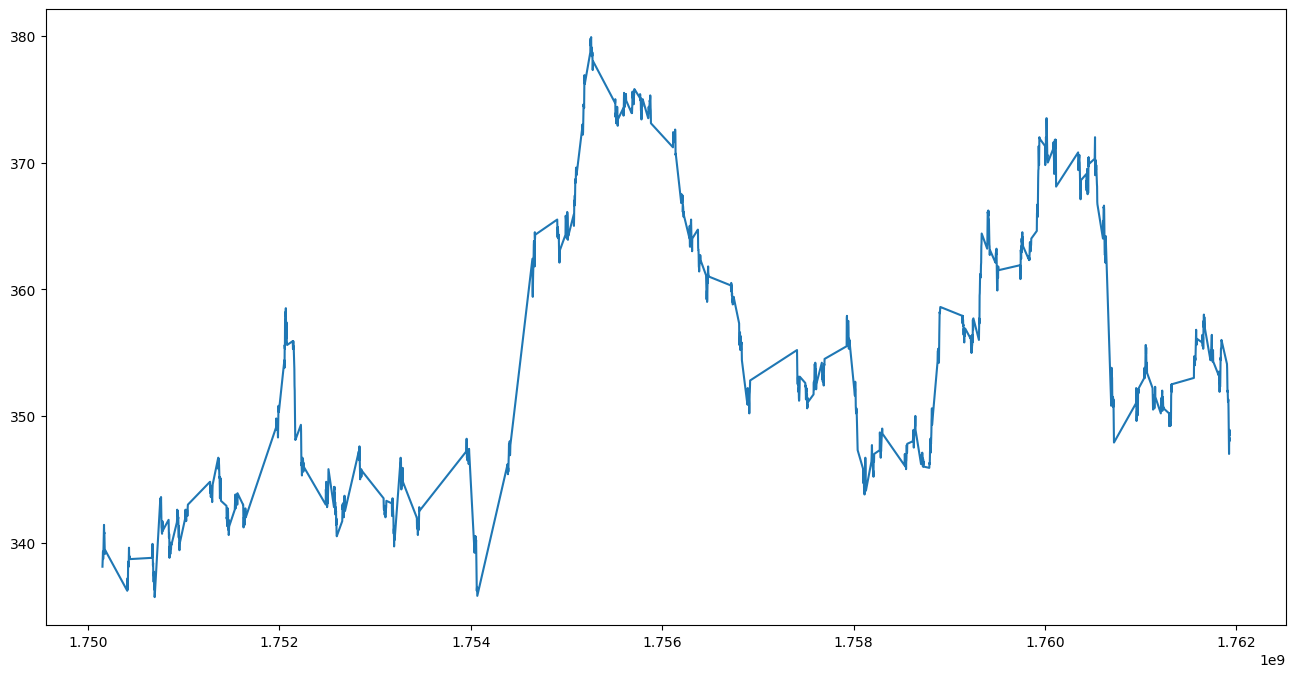

In [13]:
from datetime import datetime, timezone
df = pd.read_csv('ALV_intraday.csv')
df['Datum'] = pd.to_datetime(df['Datum'])
df['Uhrzeit'] = pd.to_timedelta(df['Uhrzeit'])
df['Timestamp'] = df['Datum'] + df['Uhrzeit']

# ISO-Strings in datetime umwandeln
df["datetime"] = pd.to_datetime(df["Timestamp"])

# In Unix-Zeitstempel (Sekunden seit 1970) konvertieren
df["unix_ts"] = df["datetime"].astype("int64") / 1e9

# print(df)
# df['unix_ts'] = df['unix_ts'] - pd.Timestamp(0)
Zeit = df['unix_ts'].to_numpy()
Kurs = df['Kurs_EUR'].to_numpy()

plt.figure(figsize=(16, 8))
plt.plot(Zeit, Kurs)

In [37]:
def penis(Zeit, Kurs, Intervall1, Intervall2, starttime = 0):
    Differenz = []
    Intervalls = []
    offset = int(starttime//1800)
    Zeit_0 = Zeit[0+offset]
    while Zeit_0 <= np.max(Zeit):
        # print('hi')
        for j in range(len(Zeit)):
            if Zeit[j] == Zeit_0 + Intervall2 and Kurs[np.where(Zeit==Zeit_0)] is not None:
                Differenz.append(Kurs[j]/Kurs[np.where(Zeit == Zeit_0)])
                Intervalls.append([Zeit_0, Zeit[j]])
        Zeit_0 += Intervall1
    return Differenz, Intervalls

In [57]:
Intervall1 = 1 * 24 * 3600
Intervall2 = 1 * 3600
starttime =  0 * 1800
Differenz, Intervalls = penis(Zeit=Zeit, Kurs=Kurs, Intervall1 = Intervall1, Intervall2=Intervall2, starttime= starttime)
Prod = np.prod(Differenz)
print(Differenz)
print(Intervalls)
print(Prod)

[array([1.0029577]), array([1.00297442]), array([1.00324677]), array([0.99912667]), array([0.99590406]), array([1.0029274]), array([1.00204742]), array([0.99796989]), array([0.99740403]), array([0.99737535]), array([1.00204315]), array([0.99795915]), array([0.99942706]), array([1.00338604]), array([0.99831412]), array([0.99370174]), array([1.00233233]), array([1.00408409]), array([1.00380447]), array([0.99942393]), array([0.99737993]), array([0.99970852]), array([0.9994221]), array([0.99766085]), array([1.00288018]), array([1.00383251]), array([0.99768914]), array([0.99172185]), array([0.99616965]), array([1.00384305]), array([0.99945345]), array([1.00107352]), array([1.00290461]), array([0.9970643]), array([0.99946572]), array([1.]), array([1.00053314]), array([1.00026775]), array([1.00215514]), array([1.00190843]), array([0.99835163]), array([0.99616116]), array([0.99695374]), array([1.00055513]), array([0.99552204]), array([1.00370481]), array([0.99408782]), array([0.99943275]), arr

In [77]:
I = 5
J = 10
K = 10
Matrix = np.zeros((I,J,K))
for i in range(1,I):
    Intervall1 = i * 24 * 3600
    for j in range(1,J):
        Intervall2 = j * 1800
        for k in range(K):
            starttime = k * 1800
            Differenz, Intervalls = penis(Zeit=Zeit, Kurs=Kurs, Intervall1 = Intervall1, Intervall2=Intervall2, starttime= starttime)
            Prod = np.prod(Differenz)
            Matrix[i,j,k] = Prod

In [80]:
print(np.max(Matrix), np.argmax(Matrix))
print(Kurs[-1]/Kurs[0])

1.0306361415296494 120
1.0307601115313207


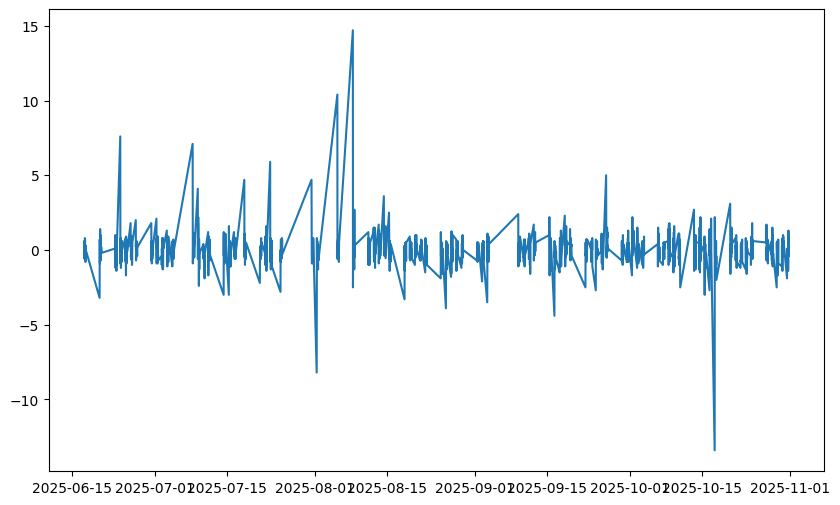

In [5]:
diff_array = df['Kurs_EUR'].diff()

plt.figure(figsize=(10, 6))
plt.plot(Zeit, diff_array)

In [6]:
import numpy as np
import datetime

# --- Beispieldaten (ersetze diese durch deine echten Daten) ---
# Erstellen wir eine plausible Zeitreihe für die Demonstration
# zeit_start = datetime.datetime(2024, 1, 1)
# anzahl_tage = 200
# Zeit-Array mit täglichen Daten
zeit = Zeit

# Kurs-Array: Eine Mischung aus stabilem Wachstum und volatilen Phasen
kurs = Kurs

# diff_array: Die Differenz zwischen aufeinanderfolgenden Kurswerten
diff_array = np.diff(kurs)
# Wir brauchen für die Analyse den Kurs und die Differenzen ab dem zweiten Tag
kurs_analyse = kurs[1:]
zeit_analyse = zeit[1:]

# --- Analyse-Parameter (diese kannst du anpassen) ---

# Größe des Zeitfensters in Tagen
fenster_groesse = 30
# Mindestwachstum in Prozent, das in diesem Fenster erreicht werden muss
wachstums_schwelle = 2
# Maximale Anzahl an Tagen, an denen der Kurs fallen darf
max_rueckgaenge = 10

# --- Analyse mit dem gleitenden Fenster ---

gefundene_intervalle = []

# Wir durchlaufen die Daten mit dem Fenster
# Der Loop stoppt, sodass das Fenster nicht über das Ende der Daten hinausragt
for i in range(len(diff_array) - fenster_groesse + 1):
    # Aktuelles Fenster aus den Daten extrahieren
    start_index = i
    end_index = i + fenster_groesse

    fenster_diff = diff_array[start_index:end_index]
    kurs_start = kurs_analyse[start_index]
    kurs_ende = kurs_analyse[end_index - 1]

    # 1. Kriterium: Wachstum berechnen
    gesamtwachstum = ((kurs_ende - kurs_start) / kurs_start) * 100

    # 2. Kriterium: Anzahl der Rückgänge zählen
    anzahl_rueckgaenge = np.sum(fenster_diff < 0)

    # Prüfen, ob beide Kriterien erfüllt sind
    if gesamtwachstum >= wachstums_schwelle and anzahl_rueckgaenge <= max_rueckgaenge:
        # Wenn ja, speichere das Start- und Enddatum des Intervalls
        intervall_start = zeit_analyse[start_index]
        intervall_ende = zeit_analyse[end_index - 1]
        gefundene_intervalle.append({
            "start": intervall_start,
            "ende": intervall_ende,
            "wachstum": gesamtwachstum,
            "rueckgaenge": anzahl_rueckgaenge
        })

# --- Ergebnisse ausgeben ---
if gefundene_intervalle:
    print(f"Es wurden {len(gefundene_intervalle)} passende Intervalle gefunden:\n")
    for intervall in gefundene_intervalle:
        print(f"Intervall: {intervall['start'].strftime('%Y-%m-%d')} bis {intervall['ende'].strftime('%Y-%m-%d')}")
        print(f"  -> Wachstum: {intervall['wachstum']:.2f}%")
        print(f"  -> Tage mit Kursrückgang: {intervall['rueckgaenge']} von {fenster_groesse} Tagen\n")
else:
    print("Keine Intervalle gefunden, die den Kriterien entsprechen.")
    print("Tipp: Versuche, die `wachstums_schwelle` zu senken oder `max_rueckgaenge` zu erhöhen.")

Es wurden 47 passende Intervalle gefunden:



AttributeError: 'numpy.datetime64' object has no attribute 'strftime'